In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("week1/insurance_claims.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nTarget distribution:\n", df["fraud_reported"].value_counts())
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Shape: (1000, 40)

Columns:
 ['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']

Target distribution:
 fraud_reported
N    753
Y    247
Name: count, dtype: int64

Missing values:
 authorities_contacted      91
_c39                     1000
dtype: int64


In [9]:
# Dropping empty column 
df.drop(columns=["_c39"], inplace=True)

# Inspecting dtypes

print("dtypes:\n", df.dtypes)
print("\nSample categoricals:")
for col in df.select_dtypes(include="object").columns:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].unique()[:5]}")


dtypes:
 months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
incident_hour_of

In [10]:
# dropping columns
drop_cols = [
    "policy_number",       # unique ID, no predictive value
    "policy_bind_date",    # would need date parsing; low signal for this model
    "incident_date",       # same
    "incident_location",   # free-text street address, too granular
    "insured_zip",         # too granular; state already captured
    "auto_model",          # too many values; make is sufficient
]
df.drop(columns=drop_cols, inplace=True)

# Fixing missing values
df["authorities_contacted"] = df["authorities_contacted"].fillna(df["authorities_contacted"].mode()[0])
df["collision_type"] = df["collision_type"].fillna("None")
df["property_damage"] = df["property_damage"].fillna(df["property_damage"].mode()[0])
df["police_report_available"] = df["police_report_available"].fillna(df["police_report_available"].mode()[0])
# Encode target
df["fraud_reported"] = df["fraud_reported"].map({"Y": 1, "N": 0})

# Encode all remaining object columns 
le = LabelEncoder()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Encoding these columns:", cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Confirm 
print("\nShape after preprocessing:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())
print("\nTarget encoded check:\n", df["fraud_reported"].value_counts()) 

Encoding these columns: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make']

Shape after preprocessing: (1000, 33)
Remaining nulls: 0

Target encoded check:
 fraud_reported
0    753
1    247
Name: count, dtype: int64


C:\Users\kelka\AppData\Local\Temp\ipykernel_23820\3214868886.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["authorities_contacted"].fillna(df["authorities_contacted"].mode()[0], inplace=True)


In [11]:
# Features and target 
X = df.drop(columns=["fraud_reported"])
y = df["fraud_reported"]

# Split: 80% train, 20% test, stratified to preserve fraud ratio 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("\nFraud rate in train:", round(y_train.mean(), 3))
print("Fraud rate in test: ", round(y_test.mean(), 3))

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train size: (800, 32)
Test size:  (200, 32)

Fraud rate in train: 0.248
Fraud rate in test:  0.245


In [12]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Decision Tree 
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)   # trees don't need scaling

print("Both models trained.")

Both models trained.


══════════════════════════════════════════════════
LOGISTIC REGRESSION
══════════════════════════════════════════════════
              precision    recall  f1-score   support

   Not Fraud       0.82      0.93      0.87       151
       Fraud       0.63      0.35      0.45        49

    accuracy                           0.79       200
   macro avg       0.72      0.64      0.66       200
weighted avg       0.77      0.79      0.77       200

══════════════════════════════════════════════════
DECISION TREE
══════════════════════════════════════════════════
              precision    recall  f1-score   support

   Not Fraud       0.90      0.83      0.87       151
       Fraud       0.58      0.71      0.64        49

    accuracy                           0.81       200
   macro avg       0.74      0.77      0.75       200
weighted avg       0.82      0.81      0.81       200

Logistic Regression ROC-AUC: 0.838
Decision Tree ROC-AUC:       0.763


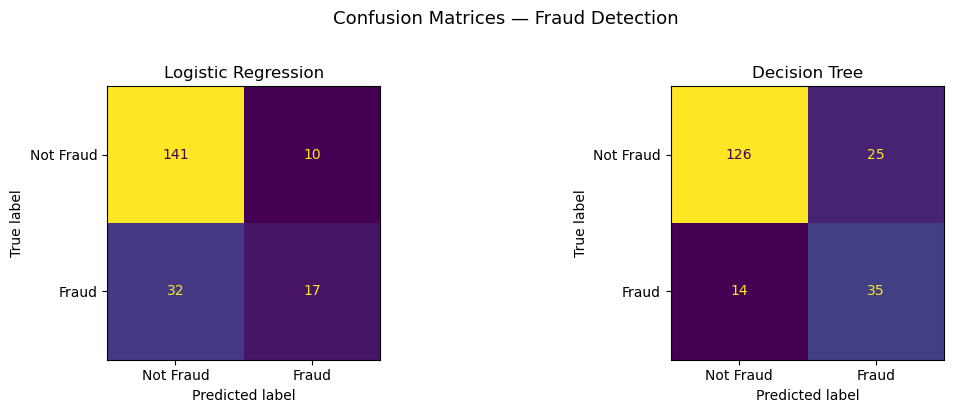

Saved: confusion_matrices.png


In [13]:
# Predictions 
lr_preds = lr.predict(X_test_scaled)
dt_preds = dt.predict(X_test)

# Classification reports 
print("═" * 50)
print("LOGISTIC REGRESSION")
print("═" * 50)
print(classification_report(y_test, lr_preds, target_names=["Not Fraud", "Fraud"]))

print("═" * 50)
print("DECISION TREE")
print("═" * 50)
print(classification_report(y_test, dt_preds, target_names=["Not Fraud", "Fraud"]))

# ROC-AUC 
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt.predict_proba(X_test)[:, 1]

print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, lr_probs):.3f}")
print(f"Decision Tree ROC-AUC:       {roc_auc_score(y_test, dt_probs):.3f}")

# Confusion matrices 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [lr_preds, dt_preds],
    ["Logistic Regression", "Decision Tree"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Fraud", "Fraud"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle("Confusion Matrices — Fraud Detection", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

In [16]:
# Generate fraud probability scores on full dataset 
# Using the decision tree (better recall) on all 1000 claims for the dashboard

X_all = df.drop(columns=["fraud_reported"])
y_all = df["fraud_reported"]

fraud_probs = dt.predict_proba(X_all)[:, 1]  

# Build export dataframe
results = pd.DataFrame({
    "claim_index"        : df.index,
    "actual_fraud"       : y_all.map({1: "Y", 0: "N"}),
    "fraud_probability"  : fraud_probs.round(3),
    "predicted_fraud"    : (fraud_probs >= 0.5).astype(int),
})

# Risk tier labels
def assign_risk_tier(prob):
    if prob >= 0.75:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    else:
        return "Low"

results["risk_tier"] = results["fraud_probability"].apply(assign_risk_tier)

# Attach key features for Power BI slicing 
feature_cols = [
    "incident_type", "incident_severity", "total_claim_amount",
    "insured_hobbies", "insured_occupation", "auto_make",
    "number_of_vehicles_involved", "witnesses", "police_report_available",
    "property_damage", "bodily_injuries",
]
results = pd.concat([results, df[feature_cols].reset_index(drop=True)], axis=1)

# Summary 
print("Risk tier distribution:\n", results["risk_tier"].value_counts())
print("\nSample output:")
print(results[["claim_index","actual_fraud","fraud_probability","risk_tier"]].head(10))

# Export 
results.to_csv("fraud_risk_scores.csv", index=False)
print("\nSaved: fraud_risk_scores.csv")

Risk tier distribution:
 risk_tier
Low       692
Medium    192
High      116
Name: count, dtype: int64

Sample output:
   claim_index actual_fraud  fraud_probability risk_tier
0            0            Y              0.560    Medium
1            1            Y              0.029       Low
2            2            N              0.025       Low
3            3            Y              0.560    Medium
4            4            N              0.025       Low
5            5            Y              0.560    Medium
6            6            N              0.250       Low
7            7            N              0.025       Low
8            8            N              0.029       Low
9            9            N              0.025       Low

Saved: fraud_risk_scores.csv


Top 15 features:

                 feature  importance
       incident_severity    0.427431
         insured_hobbies    0.397859
           vehicle_claim    0.039293
   policy_annual_premium    0.028782
 police_report_available    0.021787
            injury_claim    0.021011
incident_hour_of_the_day    0.018148
      months_as_customer    0.016804
          property_claim    0.007408
 insured_education_level    0.005763
   authorities_contacted    0.005763
            capital-loss    0.005001
                     age    0.004950
         property_damage    0.000000
               auto_make    0.000000


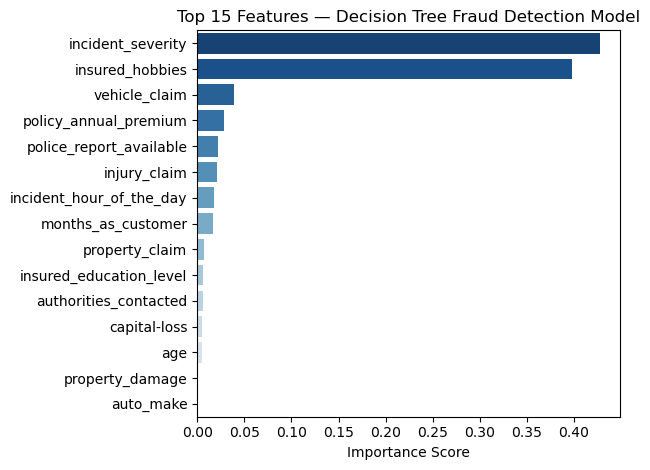

Saved: feature_importance.png


In [17]:
# Feature importance from Decision Tree
importance_df = pd.DataFrame({
    "feature"   : X.columns,
    "importance": dt.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 15 features:\n")
print(importance_df.head(15).to_string(index=False))

# Plot
sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature",
    hue="feature",
    palette="Blues_r",
    legend=False
)
plt.title("Top 15 Features — Decision Tree Fraud Detection Model")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")



In [18]:
# Final summary print 
summary = """
╔══════════════════════════════════════════════════════════════╗
║         PROJECT 3: INSURANCE FRAUD DETECTION MODEL          ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset        : insurance_claims.csv (1,000 rows, 40 col) ║
║  Target         : fraud_reported (24.7% positive rate)      ║
║  Train/Test     : 800 / 200 (stratified split)              ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL COMPARISON (test set, n=200)                         ║
║                                                             ║
║                    Logistic Reg.    Decision Tree           ║
║  Fraud Recall           0.35            0.71               ║
║  Fraud Precision        0.63            0.58               ║
║  Fraud F1               0.45            0.64               ║
║  ROC-AUC                0.838           0.763              ║
╠══════════════════════════════════════════════════════════════╣
║  SELECTED MODEL : Decision Tree (max_depth=5)               ║
║  Rationale      : Higher fraud recall (0.71 vs 0.35)        ║
║                   In fraud detection, missing fraud (FN)    ║
║                   is costlier than false alerts (FP)        ║
╠══════════════════════════════════════════════════════════════╣
║  TOP PREDICTORS : incident_severity (0.43)                  ║
║                   insured_hobbies   (0.40)                  ║
║                   vehicle_claim     (0.04)                  ║
╠══════════════════════════════════════════════════════════════╣
║  OUTPUT         : fraud_risk_scores.csv                     ║
║  Risk tiers     : High=116  Medium=192  Low=692             ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║         PROJECT 3: INSURANCE FRAUD DETECTION MODEL          ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset        : insurance_claims.csv (1,000 rows, 40 col) ║
║  Target         : fraud_reported (24.7% positive rate)      ║
║  Train/Test     : 800 / 200 (stratified split)              ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL COMPARISON (test set, n=200)                         ║
║                                                             ║
║                    Logistic Reg.    Decision Tree           ║
║  Fraud Recall           0.35            0.71               ║
║  Fraud Precision        0.63            0.58               ║
║  Fraud F1               0.45            0.64               ║
║  ROC-AUC                0.838           0.763              ║
╠══════════════════════════════════════════════════════════════╣
║  SELECTED MODEL : Decision Tree (max_

In [24]:
# Confirm if Project 3's data support Project 1's single vehicle collision finding?
df_raw = pd.read_csv("week1/insurance_claims.csv")

fraud_by_incident = df_raw.groupby("incident_type")["fraud_reported"].apply(
    lambda x: (x == "Y").mean()
).sort_values(ascending=False)

print(fraud_by_incident)

incident_type
Single Vehicle Collision    0.290323
Multi-vehicle Collision     0.272076
Parked Car                  0.095238
Vehicle Theft               0.085106
Name: fraud_reported, dtype: float64
